In [2]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib ipympl

## échauffement : le broadcasting

In [3]:
a = np.array([1, 2, 3])

# Question 1

print(a[:,None].shape)
print(a[None,:].shape)

(3, 1)
(1, 3)


In [4]:
# Question 2

print((a[:,None]-a[None,:]).shape)
print(a[:,None]-a[None,:])
# l'élément [i,j] contient a[j]-a[i]

(3, 3)
[[ 0 -1 -2]
 [ 1  0 -1]
 [ 2  1  0]]


In [ ]:
# Question 3

b = np.arange(6).reshape((2,3))
print(b)
print((b[:, None, :] - b[:, :, None]).shape)
print(b[:, None, :] - b[:, :, None])
# l'élément [i,j,k] contient b[i,k]-b[i,j]

[[0 1 2]
 [3 4 5]]
(2, 3, 3)
[[[ 0  1  2]
  [-1  0  1]
  [-2 -1  0]]

 [[ 0  1  2]
  [-1  0  1]
  [-2 -1  0]]]


## initialisation aléatoire

In [ ]:
mass_max = 3.
    
x_min, x_max = -10., 10.
y_min, y_max = -10., 10.

speed_max = 1.

def init_problem(N):
    """
    retourne un tuple masses, positions, speeds
    de formes resp.   (N,)    (2, N)     (2, N)
    tiré au sort dans les bornes définies ci-dessus
    """
    masses = np.random.uniform(0.00000001,mass_max,size=(N,))
    positions = np.random.uniform(np.array([[x_min],[y_min]]),np.array([[x_max],[y_max]]),size=(2,N))
    speeds = np.random.uniform(-speed_max,speed_max,size=(2,N))
    return masses, positions, speeds


# test

masses, positions, speeds = init_problem(10)

try:
    assert masses.shape == (10,) and positions.shape == speeds.shape == (2, 10)
    print("OK")
except:
    print("KO")

OK


## initialisation reproductible

In [ ]:
def init3():
    masses = np.array([3, 1, 1], dtype=float)
    positions = np.array([
        [0, 5, -5], 
        [0, 1, -1]], dtype=float)
    speeds = np.array([
        [0, -1, 1], 
        [0, 0, 0]], dtype=float)
    return masses, positions, speeds


## les forces

In [27]:

def forces(masses, positions, G=1.0):
    """
    returns an array of shape (2,  N)
    that contains the force felt by each mass from all the others
    G is the Newton constant and by default is set to 1 
    (we have abstract units anyway)
    """
    tab_1 = positions[:,None,:] - positions[:,:,None]
    # matrice des rj-ri de forme (2,N,N)
    tab_2 = np.sqrt(tab_1[0,:,:]**2 + tab_1[1,:,:]**2)
    # matrice des |rj-ri| de forme (N,N) (même résultat que tab_2 = np.linalg.norm(tab_1,axis=0) après test)
    np.fill_diagonal(tab_2,np.inf)
    tab_3 = G*masses[:,None]*masses[None,:]*tab_1/tab_2**3
    tab_4 = np.sum(tab_3, axis=2)
    return tab_4


# test

masses, positions, speeds = init3()

f = forces(masses, positions)

np.all(np.isclose(f, np.array([
    [ 0.        , -0.12257258,  0.12257258],
    [ 0.        , -0.02451452,  0.02451452]])))


np.True_

## le simulateur

In [30]:
def simulate(masses, positions, speeds, dt=0.1, nb_steps=100):
    """
    should return the positions across time
    so an array of shape (nb_steps, 2, N)
    optional dt is the time step
    """
    dim,N = positions.shape
    traj = np.zeros((nb_steps,dim,N))
    for i in range(nb_steps) :
        traj[i] = positions
        a = forces(masses, positions)/masses[None,:]
        speeds = speeds + a*dt
        positions = positions + speeds*dt
    return traj


# test 1

SMALL_STEPS = 4

s = simulate(masses, positions, speeds, nb_steps=SMALL_STEPS)

try:
    if s.shape == (SMALL_STEPS, 2, 3):
        print("shape OK")
except Exception as exc:
    print(f"OOPS {type(exc)} {exc}")


# test 2

positions1 = s[1]

np.all(np.isclose(positions1, np.array([
    [ 0.        ,  4.89877427, -4.89877427],
    [ 0.        ,  0.99975485, -0.99975485]
])))


shape OK


np.True_

## dessiner

<Axes: >

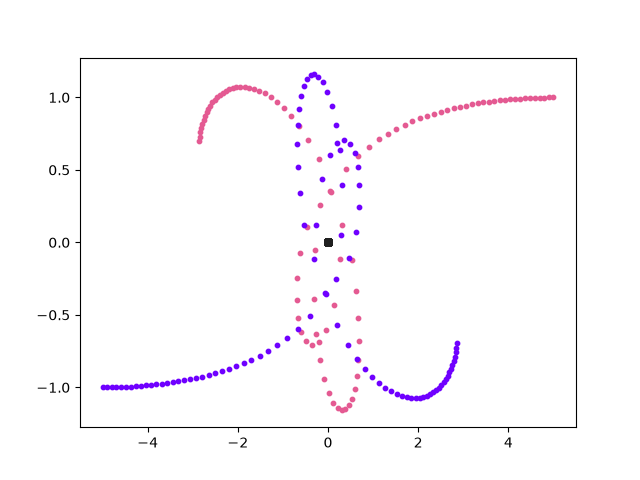

In [ ]:
def draw(simulation, masses, colors=None, scale=10.):
    """
    takes as input the result of simulate() above,
    and draws the nb_steps positions of each of the N bodies
    ideally it should return a matplotlib Axes object

    one can provide a collection of N colors to use for each body
    if not provided this is randomized

    also the optional scale parameter is used as a constant
    multiplier to obtain the final size of each dot on the figure
    """
    fig, ax = plt.subplots()
    _,_,N = simulation.shape
    for i in range(N) : 
        if colors is None :
            ax.scatter(*(simulation[:,:,i].T), color = np.random.rand(3), s = scale*masses[i])
        else :
            ax.scatter(*(simulation[:,:,i].T), color = colors[i], s = scale*masses[i])
    return ax

colors3 = np.array([
    [32, 32, 32],
    (228, 90, 146),
    (111, 0, 255),
]) / 255

masses, positions, speeds = init3()
draw(simulate(masses, positions, speeds), masses, colors3)
    

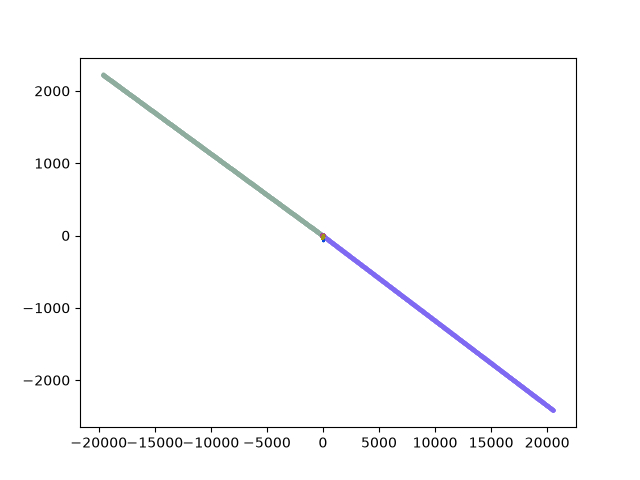

In [39]:
m5, p5, s5 = init_problem(5)
sim5 = simulate(m5, p5, s5, nb_steps=1000)
draw(sim5, m5, scale=3);
plt.savefig("random5.png")